In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import joblib
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import geopandas as gpd
from shapely.geometry import Point

In [20]:
df = pd.read_csv("model_data_knn_before_encoding.csv")
artifacts = joblib.load("preprocessing_artifacts.joblib")

test_month = artifacts["test_month"]
target = artifacts["target"]
numeric_cols = artifacts["numeric_cols"]
categorical_cols = artifacts["categorical_cols"]

df["SaleMonth"] = df["SaleMonth"].astype(str)
train_df = df[df["SaleMonth"] != test_month].copy()
test_df = df[df["SaleMonth"] == test_month].copy()

print("Test month:", test_month)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Test month: 2026-05
Train shape: (129813, 56)
Test shape: (12024, 56)


/tmp/ipykernel_3966/66538136.py:1: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("model_data_knn_before_encoding.csv")
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KNNImputer from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12

In [21]:
print(train_df[numeric_cols + categorical_cols].isna().sum())

Latitude                 0
Longitude                0
LivingArea               0
ParkingTotal             0
YearBuilt                0
BathroomsTotalInteger    0
BedroomsTotal            0
MainLevelBedrooms        0
GarageSpaces             0
AssociationFee           0
LotSizeSquareFeet        0
Flooring_missing         0
has_carpet               0
has_tile                 0
has_wood                 0
has_vinyl                0
has_laminate             0
has_stone                0
has_concrete             0
has_bamboo               0
has_brick                0
Flooring_see_remarks     0
Levels_missing           0
level_one                0
level_two                0
level_three_or_more      0
level_multisplit         0
ViewYN                   0
PoolPrivateYN            0
AttachedGarageYN         0
FireplaceYN              0
NewConstructionYN        0
HighSchoolDistrict       0
PostalCode               0
dtype: int64


In [22]:
# NEW STUFF

# Unified school district using geographic boundaries

# Load the California school district GeoJSON file
districts = gpd.read_file("DistrictAreasGeoJSON.geojson")

print("School district columns:")
print(districts.columns.tolist())

# Keep only unified school districts
districts = districts[districts["DistrictType"] == "Unified"].copy()

# Keep only the district name and polygon geometry
districts = districts[["DistrictName", "geometry"]].copy()

# Make sure the district boundaries use latitude/longitude coordinates
districts = districts.to_crs("EPSG:4326")

# Create a temporary row identifier so the original order can be restored
df["_row_id"] = np.arange(len(df))

# Only create geographic points where coordinates are available
valid_coordinates = (df["Latitude"].notna() &df["Longitude"].notna())

housing_valid = df.loc[valid_coordinates].copy()

housing_geo = gpd.GeoDataFrame(housing_valid,geometry=gpd.points_from_xy(housing_valid["Longitude"],housing_valid["Latitude"]),crs="EPSG:4326")

# Match each property point to the unified school district polygon
housing_geo = gpd.sjoin(housing_geo,districts,how="left",predicate="within")

# Keep only the new district result from the spatial join
district_mapping = housing_geo[["_row_id", "DistrictName"]].copy()

# Add DistrictName back to the full housing DataFrame
housing = df.merge(district_mapping,on="_row_id",how="left")

housing = housing.drop(columns="_row_id")

print("\nSchool district mapping completed.")
print(housing["DistrictName"].value_counts(dropna=False).head(10))
print("Properties without a mapped district:",housing["DistrictName"].isna().sum())

# Create original engineered features

# Create SaleYear from SaleMonth
housing["SaleYear"] = housing["SaleMonth"].str[:4].astype(int)

# Age of property at the time represented by the data
housing["HouseAge"] = (housing["SaleYear"] - housing["YearBuilt"])

# Remove impossible house ages
housing.loc[(housing["HouseAge"] < 0) |(housing["HouseAge"] > 250),"HouseAge"] = np.nan

# Bathrooms per bedroom
housing["BathroomsPerBedroom"] = (housing["BathroomsTotalInteger"] /housing["BedroomsTotal"].replace(0, np.nan))

# Living area per bedroom
housing["LivingAreaPerBedroom"] = (housing["LivingArea"] / housing["BedroomsTotal"].replace(0, np.nan))

# Lot size relative to living area
housing["LotToLivingAreaRatio"] = (housing["LotSizeSquareFeet"] /housing["LivingArea"].replace(0, np.nan))

# Parking availability
housing["HasParking"] = (housing["ParkingTotal"].fillna(0).gt(0).astype("int8"))

# Garage availability
housing["HasGarage"] = (housing["GarageSpaces"].fillna(0).gt(0).astype("int8"))

School district columns:
['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh', 'GradeLowCensus', 'GradeHighCensus', 'AssistStatus', 'UpdateNotes', 'EnrollTotal', 'EnrollCharter', 'EnrollNonCharter', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAreaSqMi', 'LocaleCode', 'LocaleDesc', 'geometry']

School district mapping completed.
DistrictName
NaN                     34237
Los Angeles Unified     14193
San Diego Unified        3831
Desert Sands Unified     2609
Capistrano Unified       2593
Palm Springs Unified     2314
Oakland Unified          1850
Long Beach Unified       1758
Corona-Norco Unified     1757
Hemet Unified            1703
Name: count, dt

In [28]:
# Combine train/test temporarily so dummy columns line up identically on both sides
train_df = housing[housing["SaleMonth"] != test_month].copy()
test_df  = housing[housing["SaleMonth"] == test_month].copy()

train_df["_split"] = "train"
test_df["_split"] = "test"

combined = pd.concat([train_df, test_df], axis=0)

# Add DistrictName to the list of columns to be one-hot encoded
columns_to_encode = categorical_cols + ["DistrictName"]

# One-hot encode categorical columns manually
combined_encoded = pd.get_dummies(combined,columns=columns_to_encode,drop_first=True)

# Split back apart
train_encoded = combined_encoded[combined_encoded["_split"] == "train"].drop(columns="_split")
test_encoded = combined_encoded[combined_encoded["_split"] == "test"].drop(columns="_split")

# Build X/y
# Define non-feature columns to explicitly exclude
non_feature_cols = [target, "SaleMonth", "CloseDate", "split"]
feature_cols = [col for col in train_encoded.columns if col not in non_feature_cols]

X_train = train_encoded[feature_cols]
y_train = train_encoded[target]
X_test = test_encoded[feature_cols]
y_test = test_encoded[target]

# Impute missing values in X_train and X_test
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# Fit
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 1189247.690137046
R2: 0.4977388389993723


In [29]:
print('B0, the intercept, is: ', model.intercept_)
print('B1, the slope, is: ', model.coef_)
print('The score is: ', model.score(X_test, y_test))

B0, the intercept, is:  -90467857.98618896
B1, the slope, is:  [-694503.53079532 -703792.00338002    1188.58056474 ...  737553.10538727
  337628.92148693  125576.81174214]
The score is:  0.4977388389993723


The coefficient analysis shows that variables like as LivingArea, BuildingAreaTotal, Latitude, LotSizeSquareFeet, and several location categorical variables had the largest influence on the model's predictions

Some related features like LotSizeSquareFeet and LotSizeAcres have very large coefficients with opposite signs which suggest multicollinearity between highly correlated variables

In [30]:
coef = pd.DataFrame({"Feature": X_train.columns,"Coefficient": model.coef_})
coef = coef.sort_values("Coefficient", key=abs, ascending=False)

coef.head(20)

,Feature,Coefficient
4256,PostalCode_93067,8.059033e+06
5449,DistrictName_Beverly Hills Unified,6.420681e+06
528,PostalCode_90024,3.974172e+06
3066,PostalCode_90024,3.974172e+06
4657,PostalCode_94121,3.815150e+06
2168,PostalCode_94121,3.815150e+06
1573,PostalCode_92657,3.723402e+06
4096,PostalCode_92657,3.723402e+06
4095,PostalCode_92657,3.645180e+06
1572,PostalCode_92657,3.645180e+06


The plot also shows that it struggles to accurately predict higher priced properties

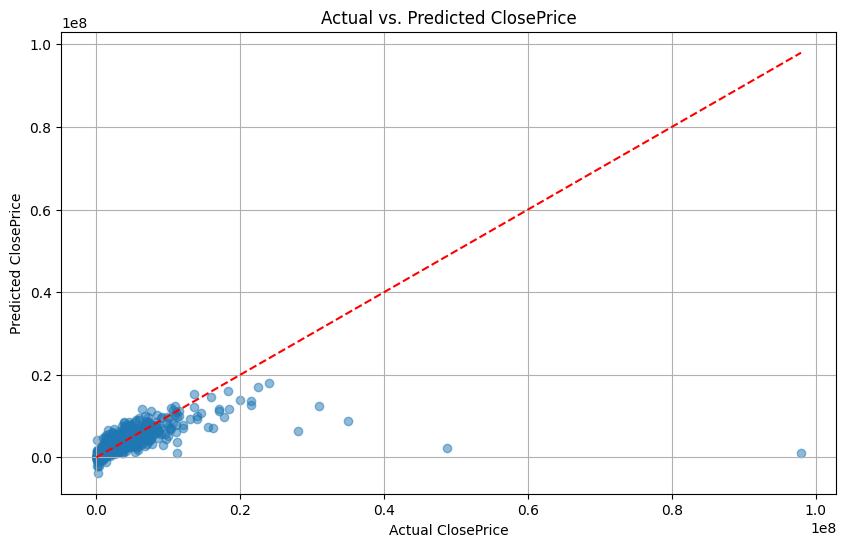

In [31]:
# Plotting actual vs. predicted values for model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs. Predicted ClosePrice")
plt.grid(True)
plt.show()

In [32]:
tree = DecisionTreeRegressor(max_depth=10,random_state=2026)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

tree_r2 = r2_score(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))

print("Decision Tree R²:", tree_r2)
print("Decision Tree RMSE:", tree_rmse)

Decision Tree R²: 0.3734941954644836
Decision Tree RMSE: 1328220.1607019145


In [33]:
forest = RandomForestRegressor(n_estimators=100,random_state=2026,n_jobs=-1)

forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)

forest_r2 = r2_score(y_test, forest_pred)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_pred))

print("Random Forest R²:", forest_r2)
print("Random Forest RMSE:", forest_rmse)

Random Forest R²: 0.5336527695999429
Random Forest RMSE: 1145940.897902656


In [34]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"],
    "R2":[
        r2,
        tree_r2,
        forest_r2],
    "RMSE":[
        rmse,
        tree_rmse,
        forest_rmse]})

print(results)

               Model        R2          RMSE
0  Linear Regression  0.497739  1.189248e+06
1      Decision Tree  0.373494  1.328220e+06
2      Random Forest  0.533653  1.145941e+06
